In [1]:
%load_ext autoreload
%autoreload 2

In [2]:


from Nozzle_2D_checkpoint4_2 import Nozzle
import matplotlib.pyplot as plt
import numpy as np
import pickle



In [3]:
SUPERCOARSE = Nozzle("inputs/RAMP_inputs.nml")
SUPERCOARSE.CFL = .1


self = SUPERCOARSE 
self.CFL = .0000001
self.iter_max = 78000

# RUN MEDIUM SIMULATION
self.set_arrays()
self.load_grid("Meshes/Inlet.53x17.grd")
#self.set_curved_geometry()
self.set_normals()
self.compute_all_areas()
self.is_foil = False


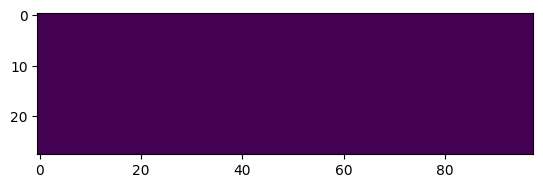

In [4]:
plt.imshow(self.V[0])

In [5]:
#self.set_initial_conditions2(direction="right",boundary_mach=.01)
self.set_initial_foil_conditions(boundary_mach=.0001)

self.set_ramp_inflow(boundary_mach=.1)
#self.set_inflow_conditions(direction="right",boundary_mach=.75)
self.V[:, -2, :] = self.V[:,-1,:]

In [6]:
#F_plus_1_2 = self.f_convective(i_plus_half=True,direction="right")+self.f_pressure_flux(i_plus_half=True,direction="right")
#F_minus_1_2 = self.f_convective(i_plus_half=False,direction="left")+self.f_pressure_flux(i_plus_half=False,direction="left")
#F_UP = self.f_convective(i_plus_half=True,direction="up")+self.f_pressure_flux(i_plus_half=True,direction="up")
#F_DOWN = self.f_convective(i_plus_half=False,direction="down")+self.f_pressure_flux(i_plus_half=False,direction="down")

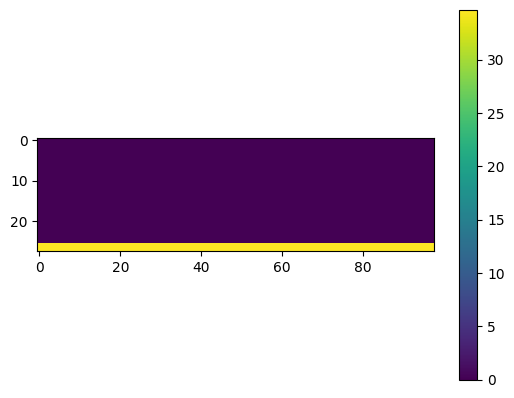

In [7]:
plt.imshow(self.V[1])
plt.colorbar()

In [9]:
plt.imshow(self.compute_residual_cell()[2])

ValueError: operands could not be broadcast together with shapes (26,96) (16,52) 

In [ ]:
self.U

array([[[7.64911601e-04, 7.64911601e-04, 7.64911601e-04, ...,
         7.64911601e-04, 7.64911601e-04, 7.64911601e-04],
        [7.64911601e-04, 7.64911601e-04, 7.64911601e-04, ...,
         7.64911601e-04, 7.64911601e-04, 7.64911601e-04],
        [7.64911601e-04, 7.64911601e-04, 7.64911601e-04, ...,
         7.64911601e-04, 7.64911601e-04, 7.64911601e-04],
        ...,
        [7.64911601e-04, 7.64911601e-04, 7.64911601e-04, ...,
         7.64911601e-04, 7.64911601e-04, 7.64911601e-04],
        [7.64911601e-04, 7.64911601e-04, 7.64911601e-04, ...,
         7.64911601e-04, 7.64911601e-04, 7.64911601e-04],
        [7.64911601e-04, 7.64911601e-04, 7.64911601e-04, ...,
         7.64911601e-04, 7.64911601e-04, 7.64911601e-04]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 

In [ ]:

#residual = self.compute_residual_cell()
self.delta_t = .01
R0 = np.linalg.norm(self.iteration_step()[0])


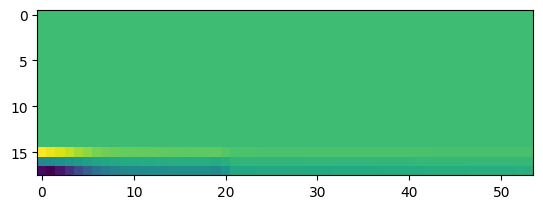

In [ ]:
plt.imshow(self.V[1])

In [ ]:
self.delta_t = self.CFL



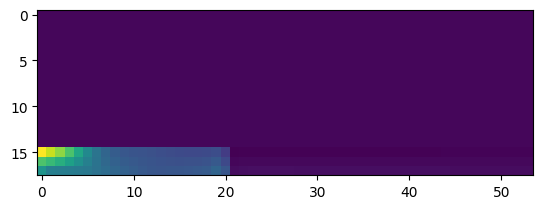

In [ ]:
plt.imshow(self.V[3])

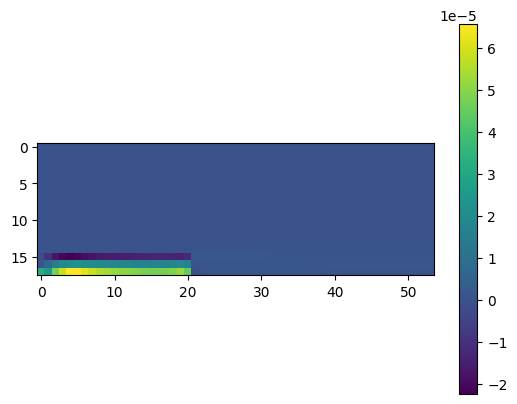

In [ ]:
plt.imshow(self.U[2])
plt.colorbar()

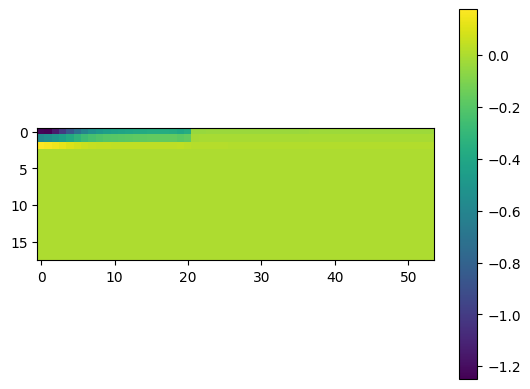

In [ ]:
#self.set_inflow_conditions(direction="right",boundary_mach=.75)
self.set_ramp_inflow(boundary_mach=4)
self.delta_t = .000001
self.U = self.primitive_to_conserved(self.V)
R0 = np.linalg.norm(self.iteration_step()[0])
plt.imshow(self.V[1,::-1])
plt.colorbar()

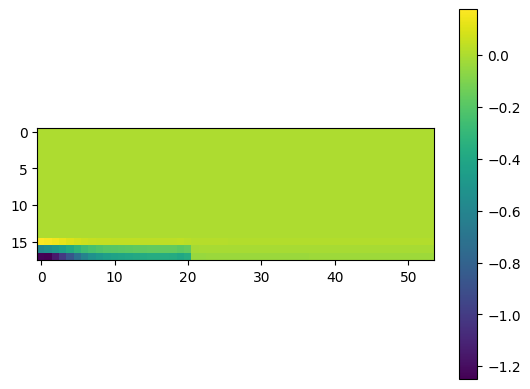

In [ ]:
plt.imshow(self.V[1])
plt.colorbar()

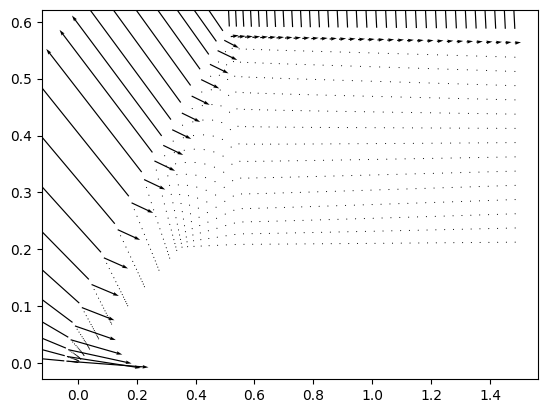

In [ ]:
self.plot_primitive("velocity")

In [ ]:
#self.V = np.load("checkpoint_V001.npy")
#self.U = np.load("checkpoint_U001.npy")

Iteration0   0.004608038257680309


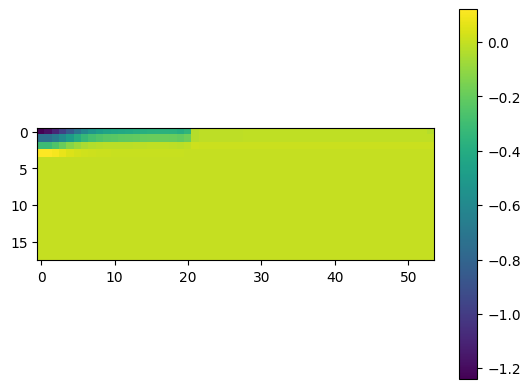

In [ ]:
self.CFL = .00001
for i in range(1):
    #self.set_ramp_inflow(boundary_mach=4)
    
    
    R1 = self.iteration_step()

    self.V[:,:,-1] = self.V[:,:,-2]
    self.set_ramp_bcs()
    
    #self.set_foil_inflow(boundary_mach=.2)
    #self.set_normal_bcs()
    #self.V[3] = np.minimum(10e+3,self.V[3])
    print(f"Iteration{i}  ",np.linalg.norm(R1[0])/(R0))
plt.imshow(self.V[1,::-1])
plt.colorbar()


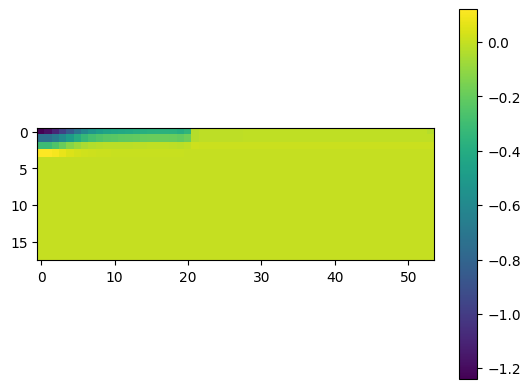

In [ ]:

plt.imshow(self.V[1,::-1])
plt.colorbar()

In [ ]:
#np.save("checkpoint_V001",self.V)
#np.save("checkpoint_U001",self.U)

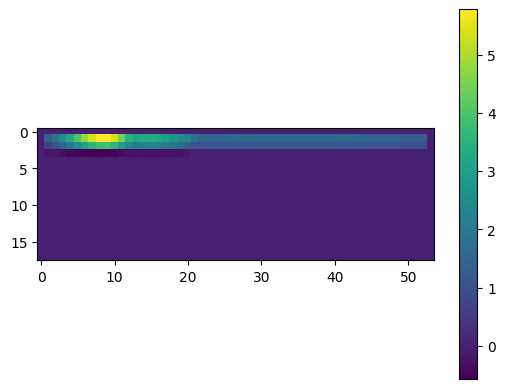

In [ ]:
plt.imshow(R1[3,::-1])
plt.colorbar()

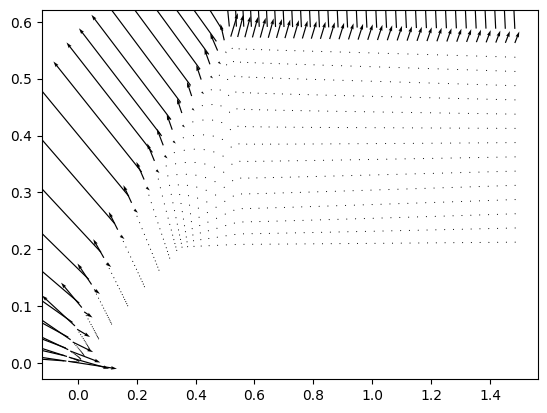

In [ ]:
self.plot_primitive("velocity")



In [ ]:
v2x = self.V[1,1,1:-1]
v2y = self.V[2,1,1:-1]
u_top,v_top = self.compute_slip_walls(self.downward_S[self.unormal,0,:],\
                                    self.downward_S[self.vnormal,0,:],self.downward_normal[self.unormal,0,:],\
                                        self.downward_normal[self.vnormal,0,:],v2x,v2y)
bottom = [u_top,v_top]